# 2.1 Basic Optimization In Julia

In this notebook, we will use the builtin optimization algorithms to find the local minimum of the functions we introduced in the previous notebook.  There are many optimization algorithms.  In this course, we will concentrate on the algorithms that require information about the gradients of univariate and multivariate functions.  Some of the methods that will be illustrated below are

* Gradient Descent
* Momentum
* Nesterov Momentum
* Adam

In [1]:
using Optimization,OptimizationOptimisers,Zygote,CairoMakie

Define structures `Point1D` and `Point2D` to hold information about the solution and call back functions `my_callback1D()` and  `my_callback2D()` to be called by the optimization function in Julia during each stage of the iteration.  In the examples here, we will use the call back functions to store the intermediate solutions of the iterative process.

In [2]:
struct Point1D
    x::Float64
    fvalue::Float64
end
struct Point2D
    x1::Float64
    x2::Float64
    fvalue::Float64
end

function my_callback1D(state, l)
    push!(vec_points,Point1D(state.u...,l))
    return false # continues the solver
end

function my_callback2D(state, l)

    push!(vec_points,Point2D(state.u...,l))
    return false # continues the solver
end;

# **Example 2.1.1**
In this example, we will show how to use the inbuilt function in Julia to find the minimum of a univariate function.  We will look at multivariate functions at the later parts of this notebook.

First we define the function $f(x)=x^2-2x+0.6$ that needs to be optimized.  Note that the variable $x$ must be a vector (not a scalar).  So we need to define it as a 1 element vector for univariate functions.


<u>Exercise Ex01:</u> Show that the minimum of this function occur at $x=1$.

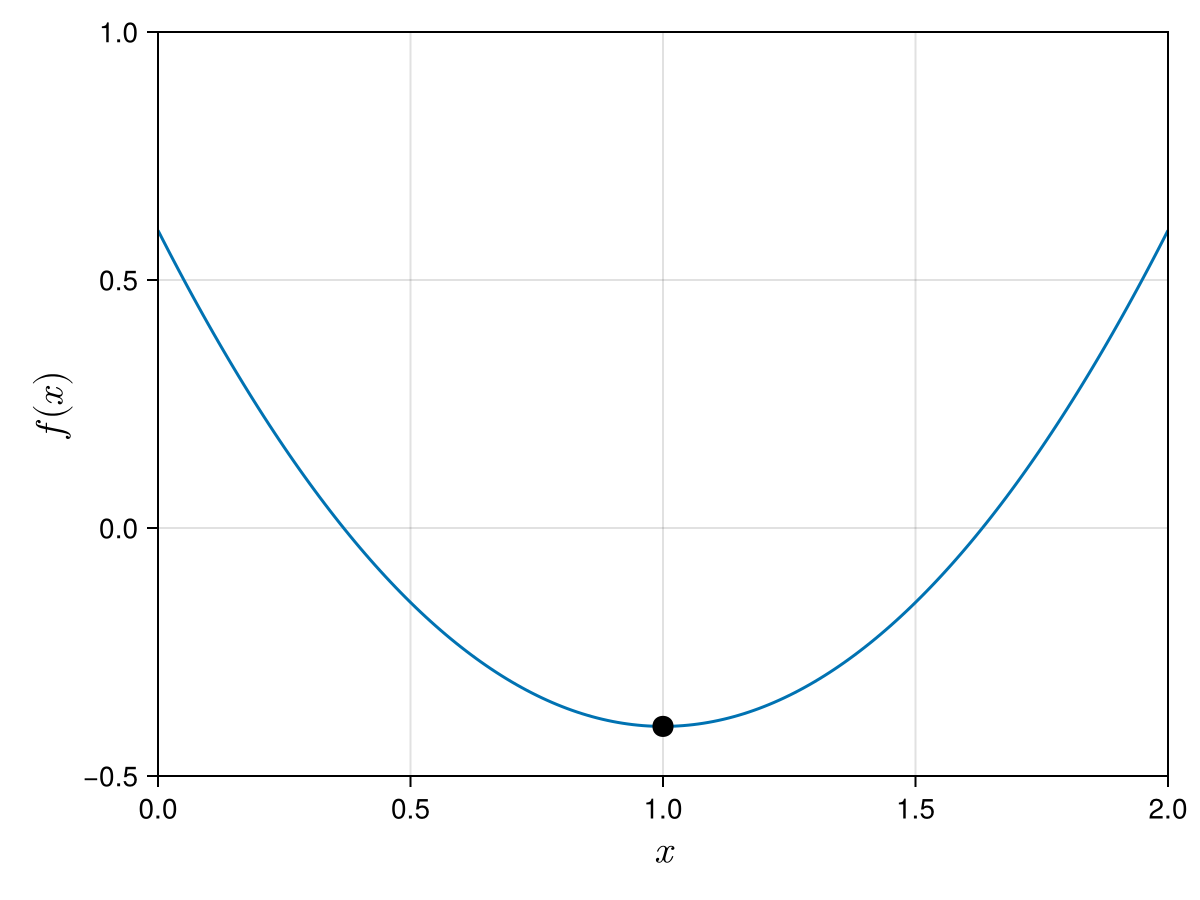

CairoMakie.Screen{IMAGE}


In [3]:
f(x)=x[1]^2-2*x[1]+0.6;  #define the function to be optimized. 

                        #NOTE that in order to use the optimisation functions, 
                        # Julia expects the input of the function to be a vector, 
                        # even if the function is univariate

xplot=0:0.01:2 #define the range to plot the function
yplot=[f(x) for x in xplot];
fig = Figure()
ax = Axis(fig[1, 1], 
    xlabel = L"x", 
    ylabel = L"f(x)",
    xlabelsize = 20, 
    ylabelsize = 20,
    limits=(0,2,-0.5,1.0))
lines!(ax,xplot,yplot)
scatter!(ax,1,f.(1);color=:black,markersize=15)
save("../figures/02p01BasicOptimizationInJulia01.svg", fig)
display(fig)

To use the `Optimization.jl` library to find the minimum of the function above,  you need to first 

* use the  `OptimizationFunction()` to specify the function (and its derivative), 
* then use `OptimizationProblem()` to define the problem and specify initial guess values 
* then use the `Optimization.solve()` function to solve the problem.  

The following code shows how you can find the minimum of the function `f(x)` defined above using the Gradient Descent method.  The standard gradient descent method has one parameter, $\alpha$.  In the example below, we have used $\alpha=0.1$.

Note that

* in general, the first argument of the `OptimizationFunction()` expects a function with two arguments `objective(x,p)`.  `x` is the variable to be minimized and `p` are (usually constant) parameters of the function to be minimized
* `Optimization.solve()` usually assumes `p` is constant and find `x` such that `objective(x,p)` is minimized.
* For the problem here, there is no `p`, so we will change the function of `x` and `p` to just `x` by writing the code `(x,p)->f(x)`

## Example 2.1.1 with Gradient Descent

In [4]:
x0=1.8*ones(1)

1-element Vector{Float64}:
 1.8

In the optimization functions that I will be using below, the functions always expects functions that takes in two variables as inputs.  In machine learning (more later) there is a reason why we would like to have functions that takes in two inputs.  We will talk more about this later.

 Since our function $f(x)$ is only a function of $x$, we have to map this function that expects two inputs to just our function of one input.  

In [5]:
temp=(x,p)->f(x)    #create a temporary function.  This function takes in two inputs x and p, but only uses x.  
                    #It will have the same output as f(x).
println(temp(4,3))
println(f(4))

8.6
8.6


In [6]:
x0=1.8*ones(1) #Define initial guess
optf = OptimizationFunction((x,p)->f(x), ADTypes.AutoZygote()) #define function to optimize and its derivative which is given by ADTypes.AutoZygote()
#optf = OptimizationFunction(temp, ADTypes.AutoZygote()) 

prob = OptimizationProblem(optf, x0) #define initial guess x=1.8
sol = solve(prob, Optimisers.Descent(0.1);maxiters=20) #solve the problem and take 20 iterations. Optimisers.Descent(0.1) asks solve to use the gradient descent optimiser with learning rate =0.1.

retcode: Default
u: 1-element Vector{Float64}:
 1.0115292150460684

In [7]:
sol.u

1-element Vector{Float64}:
 1.0115292150460684

* The output above shows that the `solve` function found the solution of the minimum of the function at $x \approx 1$.    Note that `solve()` returns the solution in a structure and the solution in the field called `u`. 

* Note that the way `solve` is called, it gives the solution after 20 iterations. In order to see the solution at the intermediate steps, you need to initiate `callback` function in the `solve` function

In [8]:
vec_points=[] #Define empty vector to store intermediate solutions

optf = OptimizationFunction((x,p)->f(x), ADTypes.AutoZygote())
prob = OptimizationProblem(optf, x0)
sol = solve(prob, Optimisers.Descent(0.1);maxiters=20,callback=my_callback1D); #the 0.1 is called the learning rate and it is a parameter you can tune in the `solve()' function

vec_points_gd=copy(vec_points);  #Copy information about the intermediate solution to vec_points_gd
vec_points

21-element Vector{Any}:
 Point1D(1.8, 0.2400000000000001)
 Point1D(1.6400000000000001, 0.009600000000000164)
 Point1D(1.512, -0.13785599999999987)
 Point1D(1.4096, -0.23222784000000007)
 Point1D(1.32768, -0.29262581759999995)
 Point1D(1.262144, -0.33128052326400004)
 Point1D(1.2097152, -0.35601953488896)
 Point1D(1.16777216, -0.3718525023289344)
 Point1D(1.1342177279999999, -0.38198560149051797)
 Point1D(1.1073741823999999, -0.3884707849539316)
 ⋮
 Point1D(1.0549755813888, -0.39697768545096335)
 Point1D(1.04398046511104, -0.3980657186886166)
 Point1D(1.035184372088832, -0.39876205996071457)
 Point1D(1.0281474976710656, -0.39920771837485736)
 Point1D(1.0225179981368524, -0.3994929397599086)
 Point1D(1.0180143985094818, -0.3996754814463416)
 Point1D(1.0144115188075855, -0.3997923081256586)
 Point1D(1.0115292150460684, -0.3998670772004215)
 Point1D(1.0115292150460684, -0.3998670772004215)

A few points to note with the numbers above

* The information above shows that we start with an intial guess of 1.8 and the value of the function is 0.24. 
* After 20 iterations, the solution obtained is $x=1.011529...$ and the value of the function is -0.3998670772004215.  So the value of the function has decreased from its initial value confirming that we are moving in a direction that decreases the value of the function.

We will now plot the information in `vec_points` to see how the solution converges.

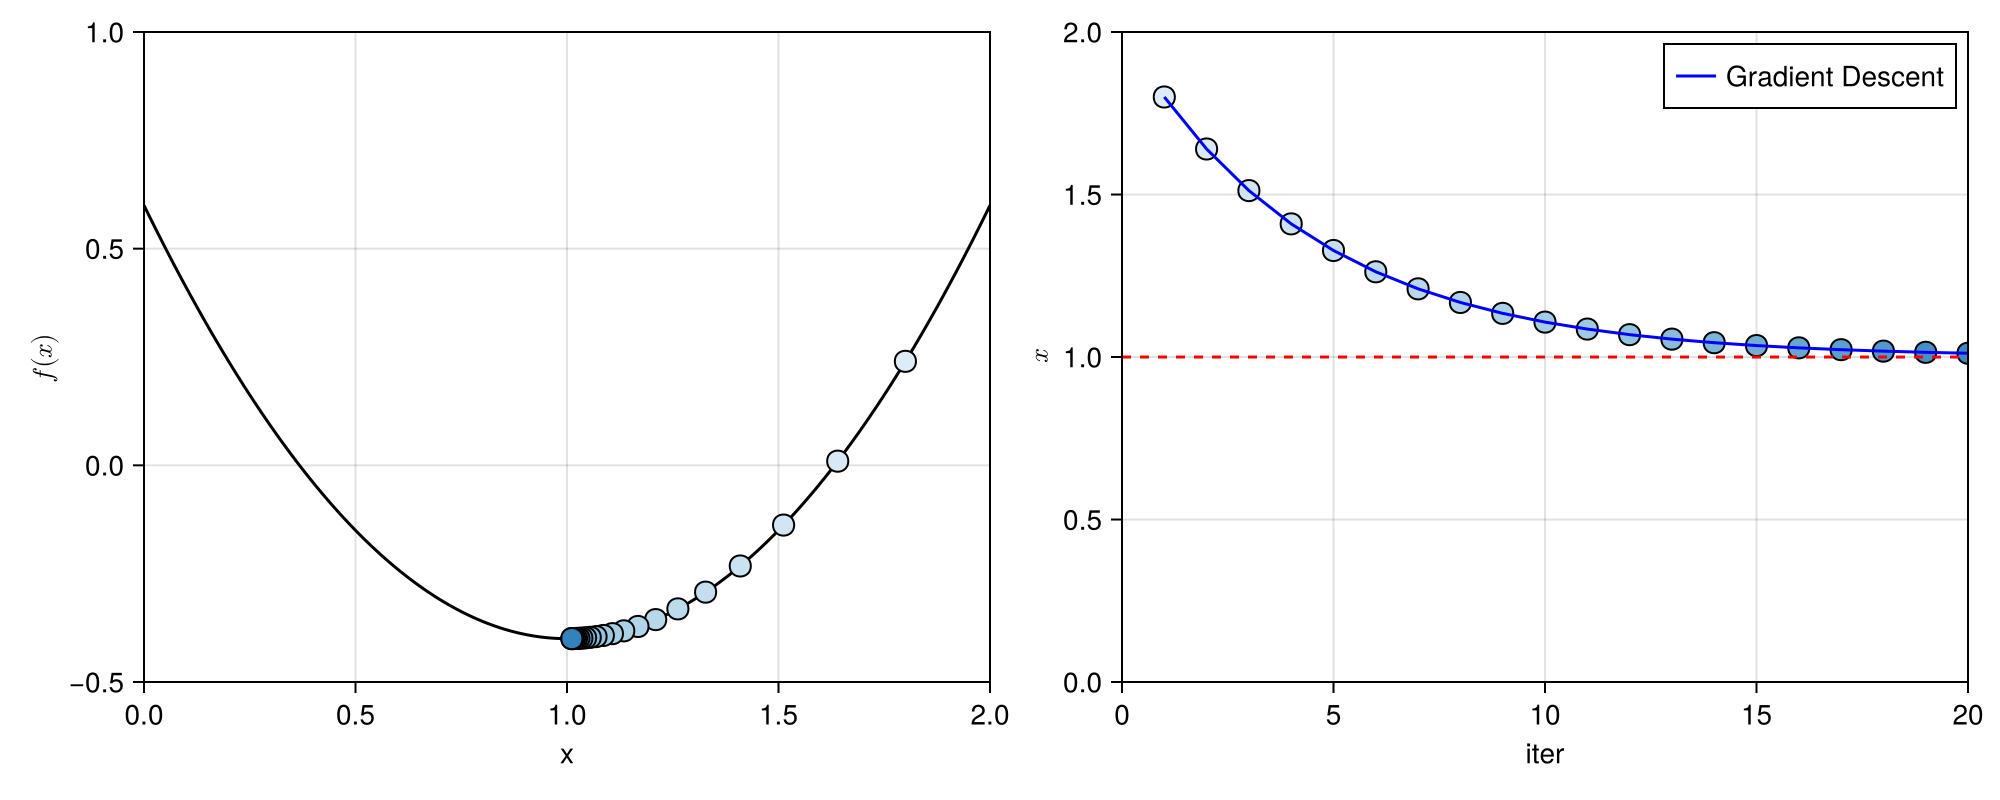

CairoMakie.Screen{IMAGE}


In [9]:
fig = Figure(size=(1000, 400))
ax1 = Axis(fig[1, 1], xlabel = "x", ylabel = L"f(x)",limits=(0,2,-0.5,1.0))
ax2 = Axis(fig[1, 2], xlabel = "iter", ylabel = L"x",limits=(0,20,0.0,2.0))
lines!(ax1,xplot,yplot;color=:black)
scatter!(ax1,getproperty.(vec_points[:],:x),getproperty.(vec_points[:],:fvalue);markersize=15,color=1:length(vec_points),colormap=:Blues_3,strokewidth=1,strokecolor=:black,label="Gradient Descent")
scatter!(ax2,getproperty.(vec_points[:],:x);markersize=15,color=1:length(vec_points),colormap=:Blues_3,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points[:],:x);color=:blue,label="Gradient Descent")
hlines!(ax2, 1.0, color=:red, linestyle=:dash) 
axislegend(ax2;position = :rt)
save("../figures/02p01BasicOptimizationInJulia02.svg", fig)
display(fig)

<u>Exercise Ex02:</u> Repeat the example above with different values of learning rate $\alpha$.  Can you think of the advantages/disadvantages of using small/large values of $\alpha$?  Try with $\alpha \in [0.01,0.8]$

## Example 2.1.1 with Momentum method

Now we will use a method called "Momentum" to find the minimum of $f(x)$.  This method has parameters called learning rate, $\alpha$, and momentum decay, $\beta$.  In the example below, we will use learning rate of $\alpha=0.1$ and momentum decay of $\beta=0.9$.
We will plot the solution over the standard gradient descent solution.

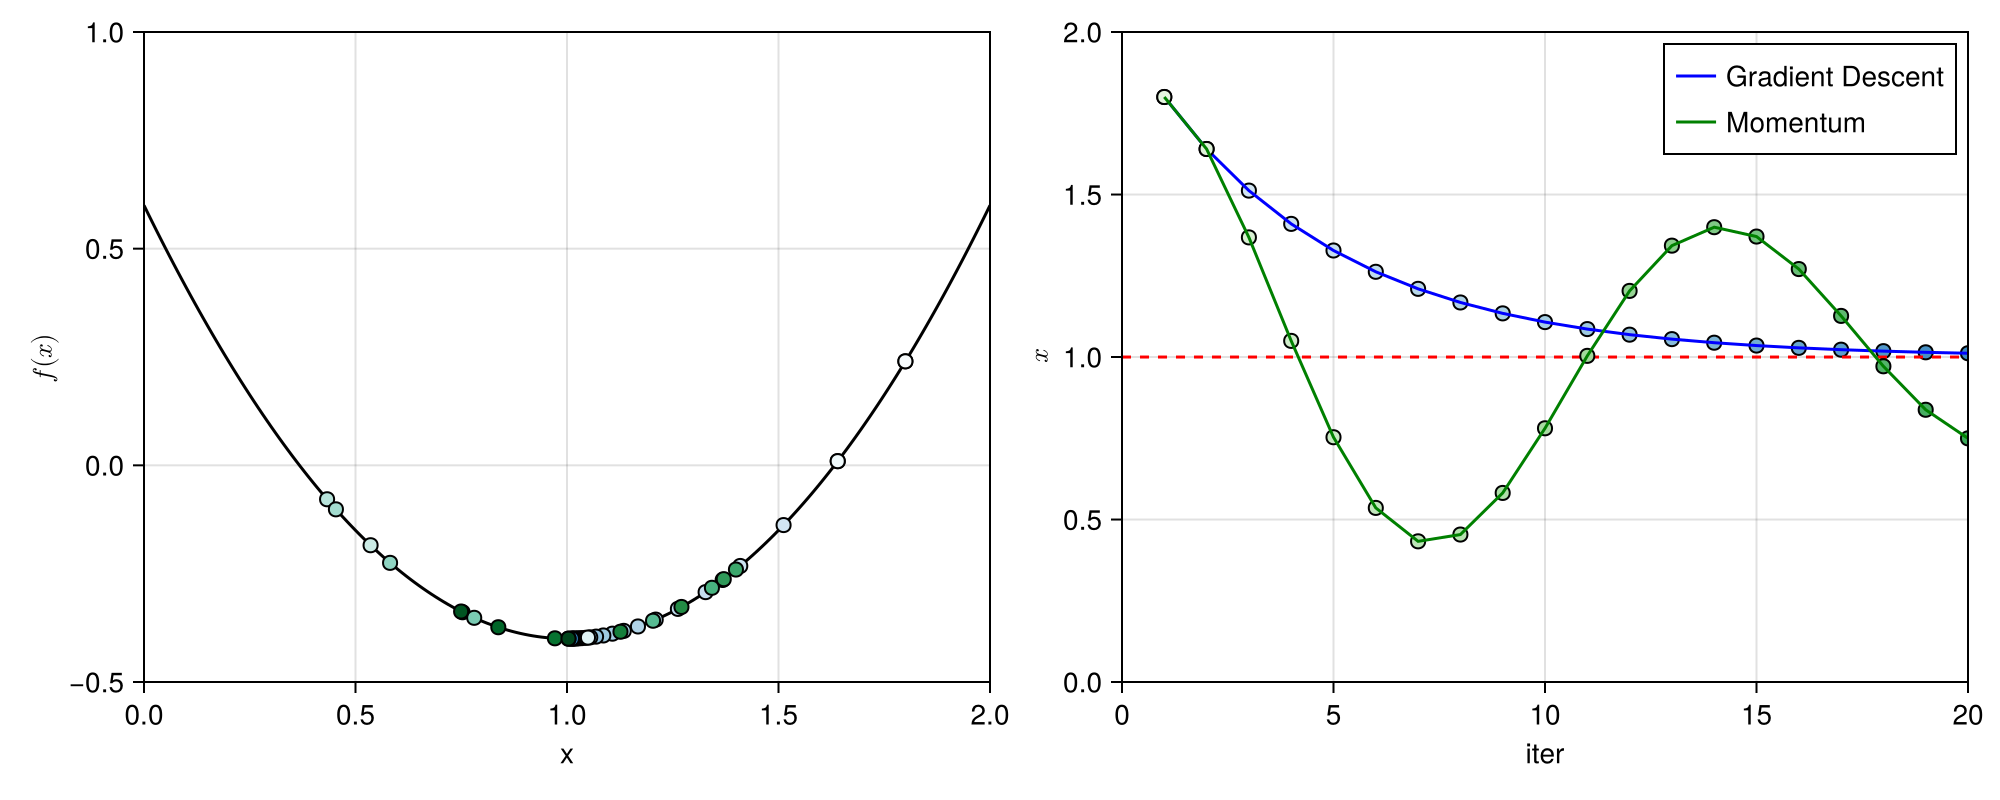

In [10]:
x0=1.8*ones(1) #Define initial guess
vec_points=[]
sol = solve(prob, Optimisers.Momentum(0.1,0.9);maxiters=20,callback=my_callback1D) #solve the problem and take 10 iterations. 

vec_points_m=copy(vec_points)

fig = Figure(size=(1000, 400))
ax1 = Axis(fig[1, 1], xlabel = "x", ylabel = L"f(x)",limits=(0,2,-0.5,1.0))
ax2 = Axis(fig[1, 2], xlabel = "iter", ylabel = L"x",limits=(0,20,0.0,2.0))
lines!(ax1,xplot,yplot;color=:black)
scatter!(ax1,getproperty.(vec_points_gd[:],:x),getproperty.(vec_points_gd[:],:fvalue);markersize=10,color=1:length(vec_points),colormap=:Blues_3,strokewidth=1,strokecolor=:black,label="Gradient Descent")
scatter!(ax2,getproperty.(vec_points_gd[:],:x);markersize=10,color=1:length(vec_points),colormap=:Blues_3,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points_gd[:],:x);color=:blue,label="Gradient Descent")
hlines!(ax2, 1.0, color=:red, linestyle=:dash) 

scatter!(ax1,getproperty.(vec_points_m[:],:x),getproperty.(vec_points_m[:],:fvalue);markersize=10,color=1:length(vec_points),colormap=:BuGn,strokewidth=1,strokecolor=:black,label="Momentum")
scatter!(ax2,getproperty.(vec_points_m[:],:x);markersize=10,color=1:length(vec_points),colormap=:Greens_3,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points[:],:x);color=:green,label="Momentum")

axislegend(ax2;position = :rt)

fig

From the graph above, it can be seen that the momentum method can quickly approach the true solution but has a tendency to overshoot the true solution at $x=1$.

<u>Exercise Ex03:</u> Repeat the example above with different values of momentum decay $\beta$.  Try using $\beta \in [0.0,0.5]$.  What happens to the intermediate solutions as you increase $\beta$?

## Example 2.1.1 with Nesterov Momentum method

Now we will use the Nesterov momentum method to try to find the local minimum.  The Nesterov momentum method has two parameters, similar to the momentum method, learning rate $\alpha$ and momentum decay, $\beta$.  We have used $\alpha=0.1$ and momentum decay, $\beta=0.9$ in the example below.

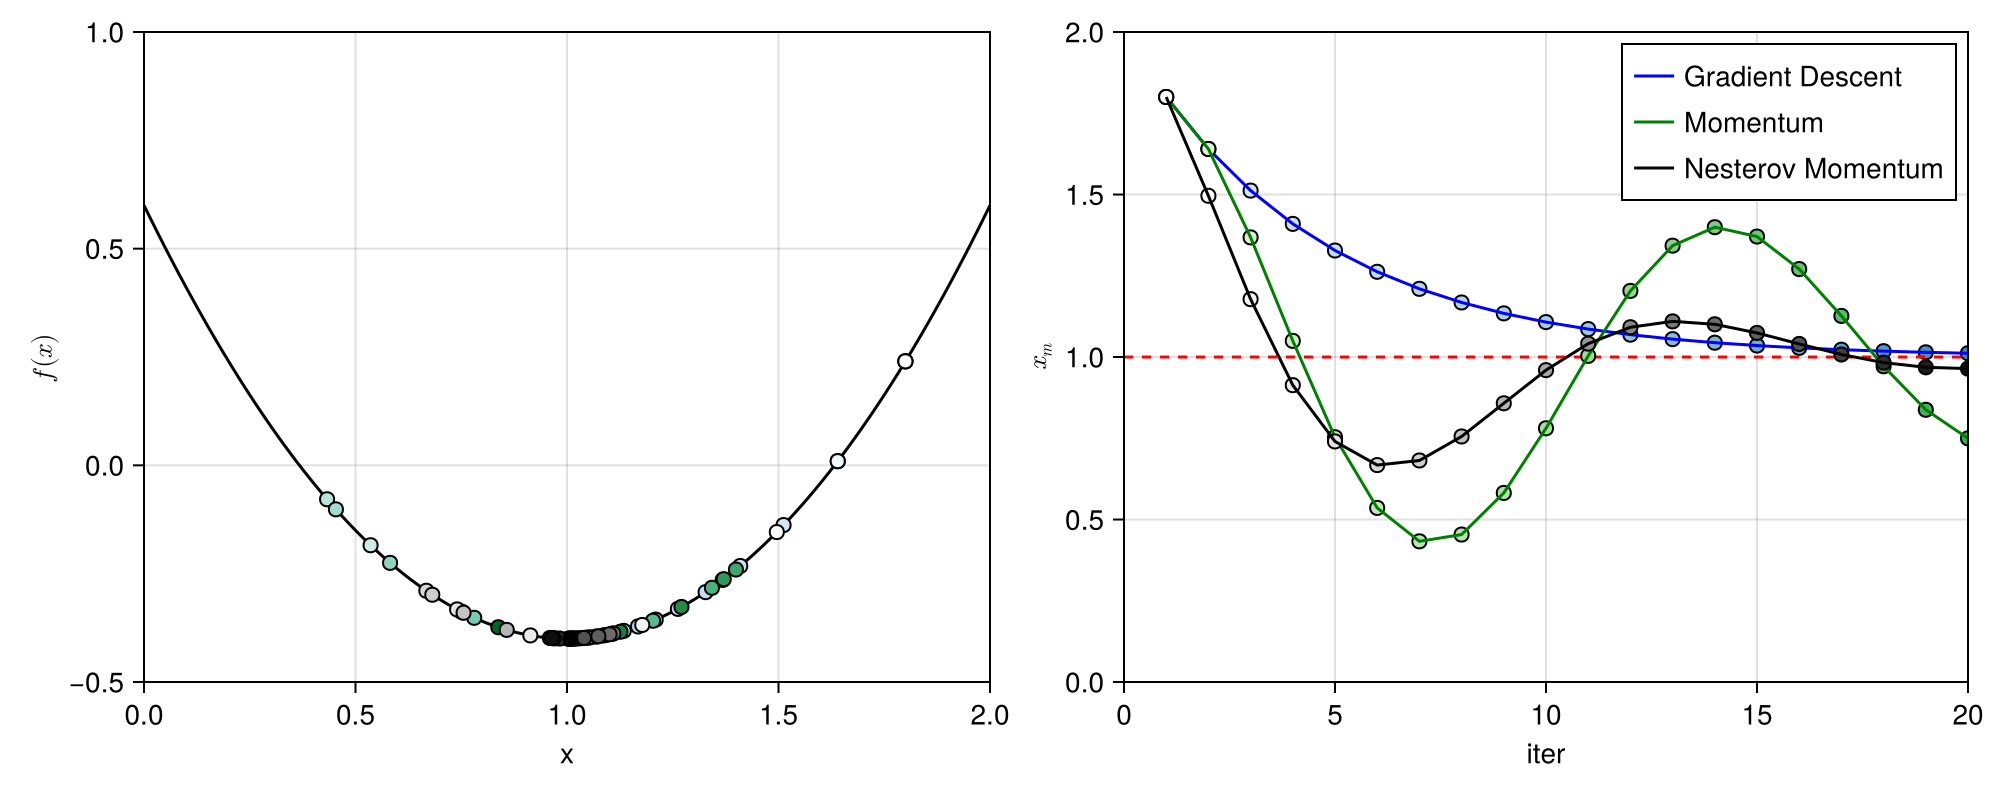

In [11]:
x0=1.8*ones(1) #Define initial guess
vec_points=[]
sol = solve(prob, Optimisers.Nesterov(0.1,0.9);maxiters=20,callback=my_callback1D) #solve the problem and take 10 iterations. 


vec_points_nm=copy(vec_points)

###
#The code below plots the intermediate solutions for all methods
#####

fig = Figure(size=(1000, 400))
ax1 = Axis(fig[1, 1], xlabel = "x", ylabel = L"f(x)",limits=(0,2,-0.5,1.0))
ax2 = Axis(fig[1, 2], xlabel = "iter", ylabel = L"x_m",limits=(0,20,0.0,2.0))
lines!(ax1,xplot,yplot;color=:black)
scatter!(ax1,getproperty.(vec_points_gd[:],:x),getproperty.(vec_points_gd[:],:fvalue);markersize=10,color=1:length(vec_points),colormap=:Blues_3,strokewidth=1,strokecolor=:black,label="Gradient Descent")
scatter!(ax2,getproperty.(vec_points_gd[:],:x);markersize=10,color=1:length(vec_points),colormap=:Blues_3,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points_gd[:],:x);color=:blue,label="Gradient Descent")
hlines!(ax2, 1.0, color=:red, linestyle=:dash) 

scatter!(ax1,getproperty.(vec_points_m[:],:x),getproperty.(vec_points_m[:],:fvalue);markersize=10,color=1:length(vec_points),colormap=:BuGn,strokewidth=1,strokecolor=:black,label="Momentum")
scatter!(ax2,getproperty.(vec_points_m[:],:x);markersize=10,color=1:length(vec_points),colormap=:Greens_3,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points_m[:],:x);color=:green,label="Momentum")

scatter!(ax1,getproperty.(vec_points_nm[:],:x),getproperty.(vec_points_nm[:],:fvalue);markersize=10,color=1:length(vec_points),colormap=:Greys,strokewidth=1,strokecolor=:black,label="Nesterov Momentum")
scatter!(ax2,getproperty.(vec_points_nm[:],:x);markersize=10,color=1:length(vec_points),colormap=:Greys,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points_nm[:],:x);color=:black,label="Nesterov Momentum")
axislegend(ax2;position = :rt)

fig

Note that the Nesterov momentum method is less oscillatory than the momentum method.

## Example 2.1.1 with Adam method 

The Adam (short for adaptive moment estimation)  method one of the most widely used method for optimization.  Its parameters are learning rate and a tuple of decay of momentums.  For the example below, we have used learning rate of 0.1 and tuple of decay of momentum to be (0.9,0.999)

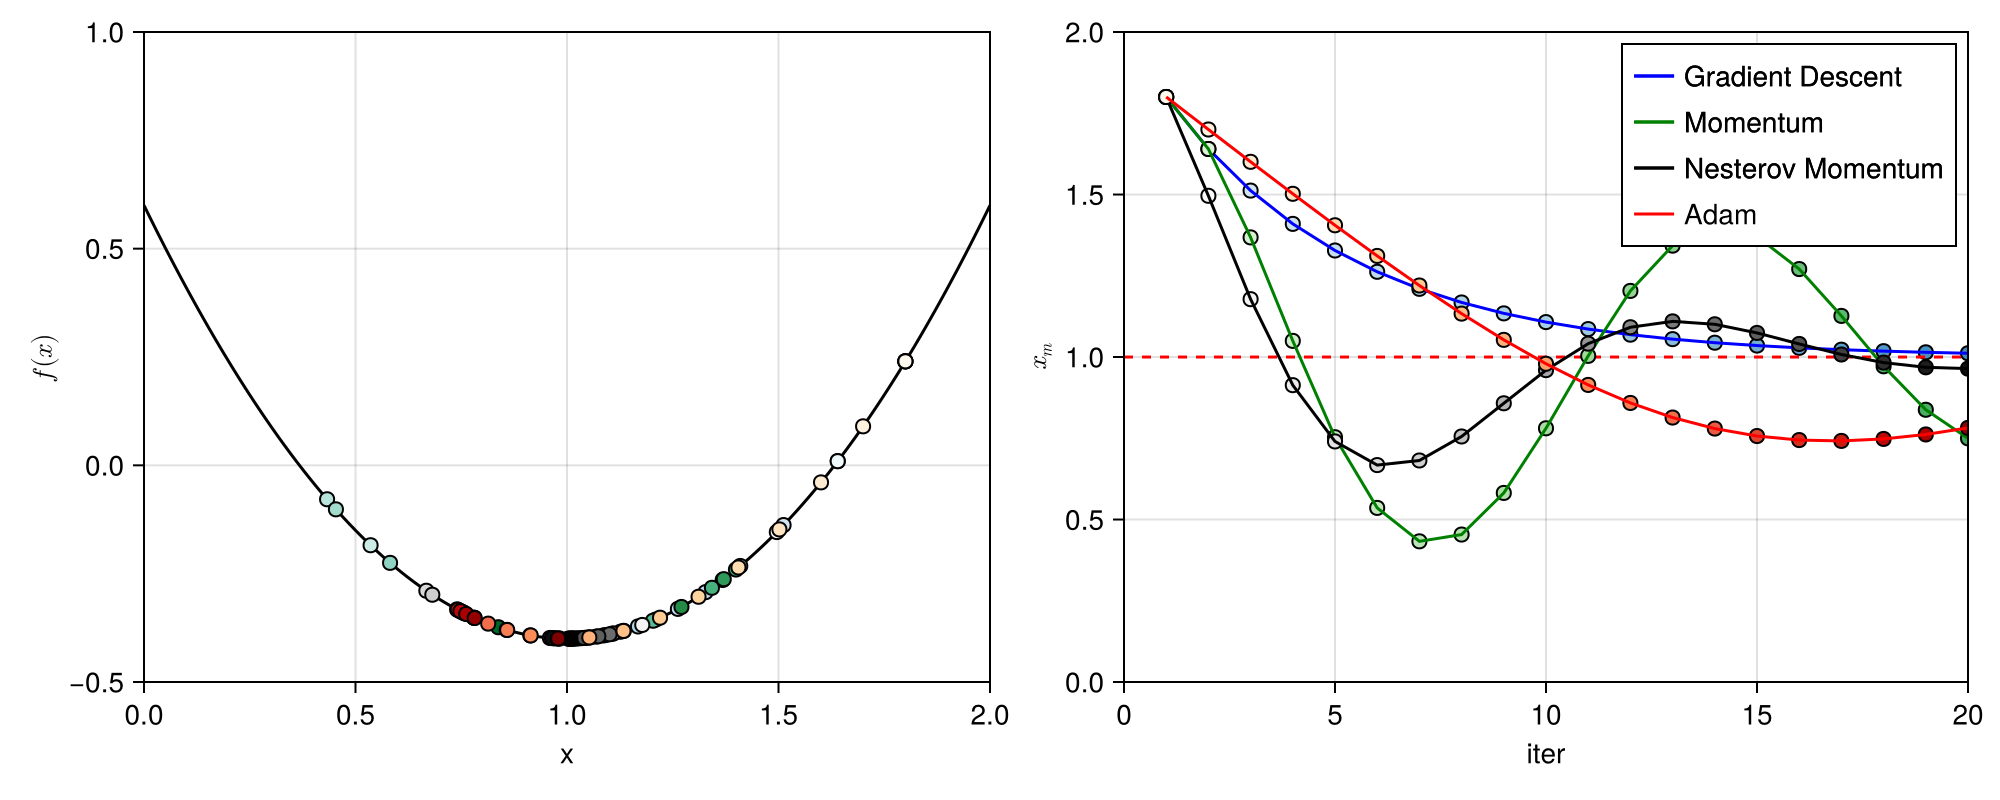

In [12]:
x0=1.8*ones(1) #Define initial guess
vec_points=[]
sol = solve(prob, Optimisers.Adam(0.1,(0.9,0.99));maxiters=20,callback=my_callback1D) #solve the problem and take 10 iterations. 

vec_points_ad=copy(vec_points)

###
#The code below plots the intermediate solutions for all methods
#####

fig = Figure(size=(1000, 400))
ax1 = Axis(fig[1, 1], xlabel = "x", ylabel = L"f(x)",limits=(0,2,-0.5,1.0))
ax2 = Axis(fig[1, 2], xlabel = "iter", ylabel = L"x_m",limits=(0,20,0.0,2.0))
lines!(ax1,xplot,yplot;color=:black)
scatter!(ax1,getproperty.(vec_points_gd[:],:x),getproperty.(vec_points_gd[:],:fvalue);markersize=10,color=1:length(vec_points),colormap=:Blues_3,strokewidth=1,strokecolor=:black,label="Gradient Descent")
scatter!(ax2,getproperty.(vec_points_gd[:],:x);markersize=10,color=1:length(vec_points),colormap=:Blues_3,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points_gd[:],:x);color=:blue,label="Gradient Descent")
hlines!(ax2, 1.0, color=:red, linestyle=:dash) 

scatter!(ax1,getproperty.(vec_points_m[:],:x),getproperty.(vec_points_m[:],:fvalue);markersize=10,color=1:length(vec_points),colormap=:BuGn,strokewidth=1,strokecolor=:black,label="Momentum")
scatter!(ax2,getproperty.(vec_points_m[:],:x);markersize=10,color=1:length(vec_points),colormap=:Greens_3,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points_m[:],:x);color=:green,label="Momentum")

scatter!(ax1,getproperty.(vec_points_nm[:],:x),getproperty.(vec_points_nm[:],:fvalue);markersize=10,color=1:length(vec_points),colormap=:Greys,strokewidth=1,strokecolor=:black,label="Nesterov Momentum")
scatter!(ax2,getproperty.(vec_points_nm[:],:x);markersize=10,color=1:length(vec_points),colormap=:Greys,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points_nm[:],:x);color=:black,label="Nesterov Momentum")
axislegend(ax2;position = :rt)

scatter!(ax1,getproperty.(vec_points_ad[:],:x),getproperty.(vec_points_ad[:],:fvalue);markersize=10,color=1:length(vec_points),colormap=:OrRd,strokewidth=1,strokecolor=:black,label="Adam")
scatter!(ax2,getproperty.(vec_points_ad[:],:x);markersize=10,color=1:length(vec_points),colormap=:OrRd,strokewidth=1,strokecolor=:black)
lines!(ax2,getproperty.(vec_points_ad[:],:x);color=:red,label="Adam")

axislegend(ax2;position = :rt)
fig


---

**Class Demo 01:**. Use one of the methods above to find the value of $r$ that minimizes the function $A(r)=2\pi r^2+\frac{2}{r}$.

---

## **Example 2.1.2**

For this next example, we will use the `Optimization.jl` package in Julia to solve a "Simple" quadratic function from "An Introduction to  the Conjugate Gradient Method  Without the Agonizing Pain"  Edition 1 1  4  Jonathan Richard Shewchuk  August 4, 1994

$f(x_1,x_2)=\frac{3}{2}x_1^2+2x_1x_2+3x_2^2-2x_1+8x_2$


<u>Exercise Ex04:</u> Show that the minimum of this function is at $(x_1,x_2)=(2,-2)$.

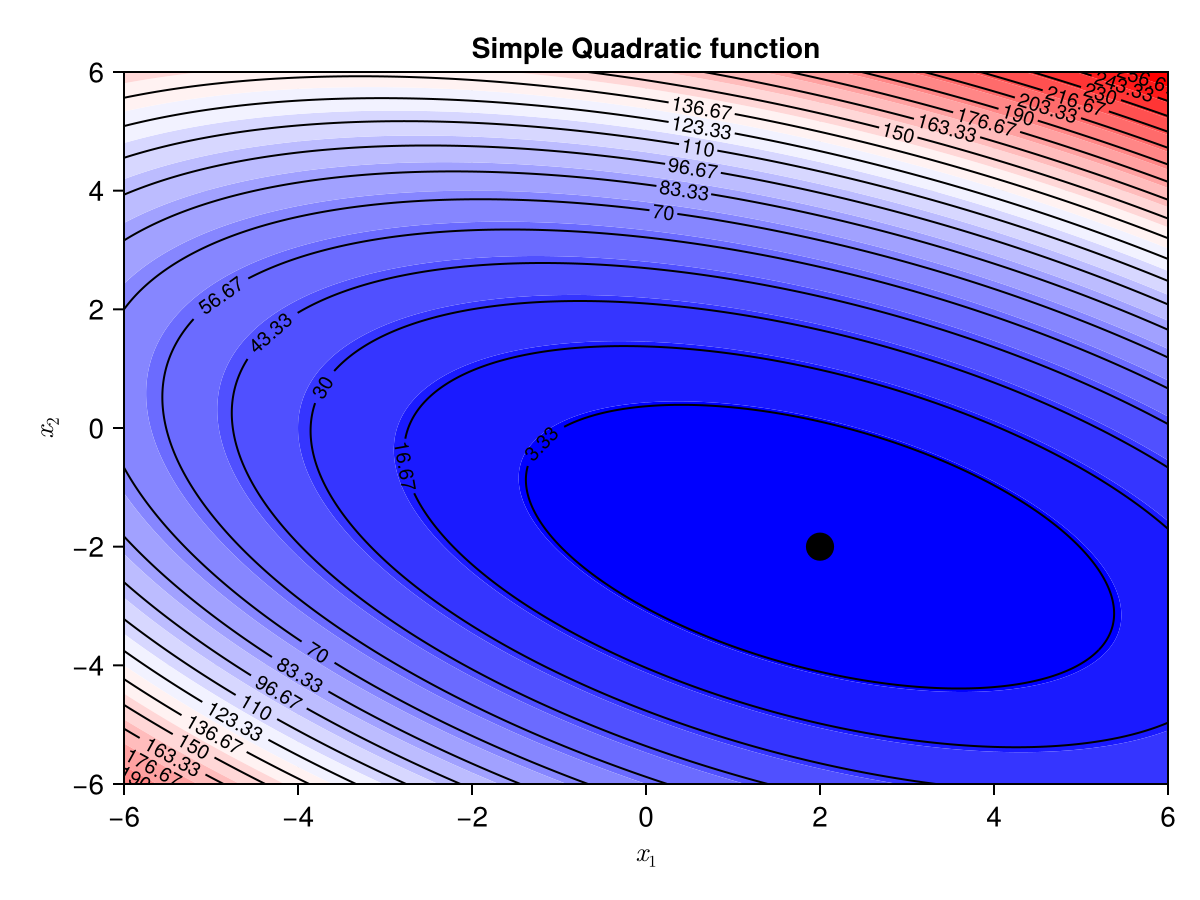

In [13]:
quad(x)=(3.0/2.0)*x[1]^2+2*x[1]*x[2]+3*x[2]^2-2*x[1]+8*x[2]

x1range=-6:0.02:6;
x2range=-6:0.02:6;
funcplot = [quad([x1,x2]) for x1 in x1range, x2 in x2range]

x = [(x1i, x2i) for x1i in x1range, x2i in x2range]
fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",title = "Simple Quadratic function",limits=(-6,6.0,-6.0,6.0))
contourf!(ax,x1range,x2range,funcplot;  levels=20,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels=20,color=:black)
scatter!(ax,[2],[-2];markersize=20,color=:black)
fig

## Example 2.1.2 with Standard Gradient Descent method

In the example below, we will use the initial guess $(x_1,x_2)=(4,4)$ and learning rate $\alpha=0.1$.

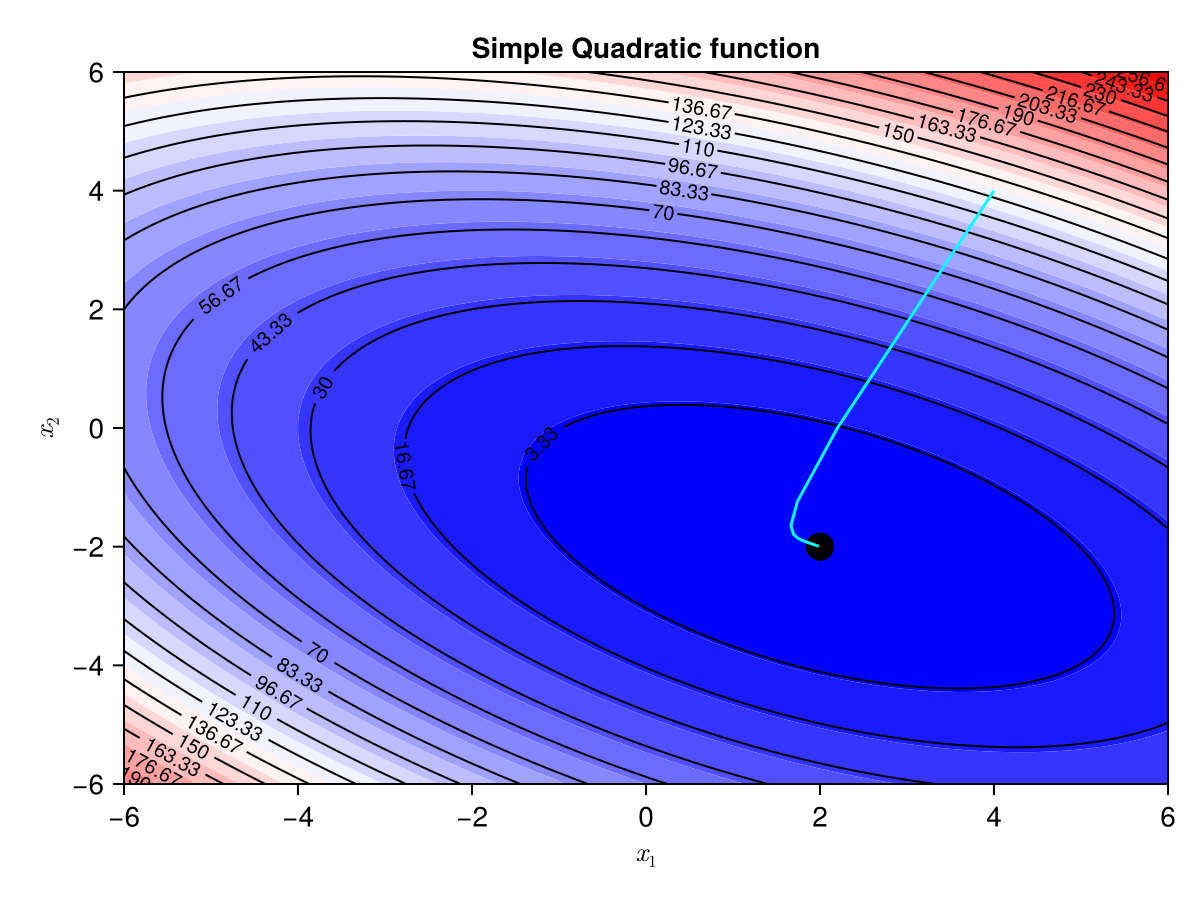

In [14]:
x0=4.0*ones(2)
vec_points=[] #Define empty vector
optf = OptimizationFunction((x,p)->quad(x), ADTypes.AutoZygote())
prob = OptimizationProblem(optf, x0)
sol = solve(prob, Optimisers.Descent(0.1);maxiters=20,callback=my_callback2D)

vec_points_gd=copy(vec_points)

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",title = "Simple Quadratic function",limits=(-6,6.0,-6.0,6.0))
contourf!(ax,x1range,x2range,funcplot;  levels=20,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels=20,color=:black)
scatter!(ax,[2],[-2];markersize=20,color=:black)

lines!(ax,getproperty.(vec_points_gd[:],:x1),getproperty.(vec_points_gd[:],:x2);color=:cyan,label="Gradient Descent")
fig

## Example 1.6.2 with Momentum method

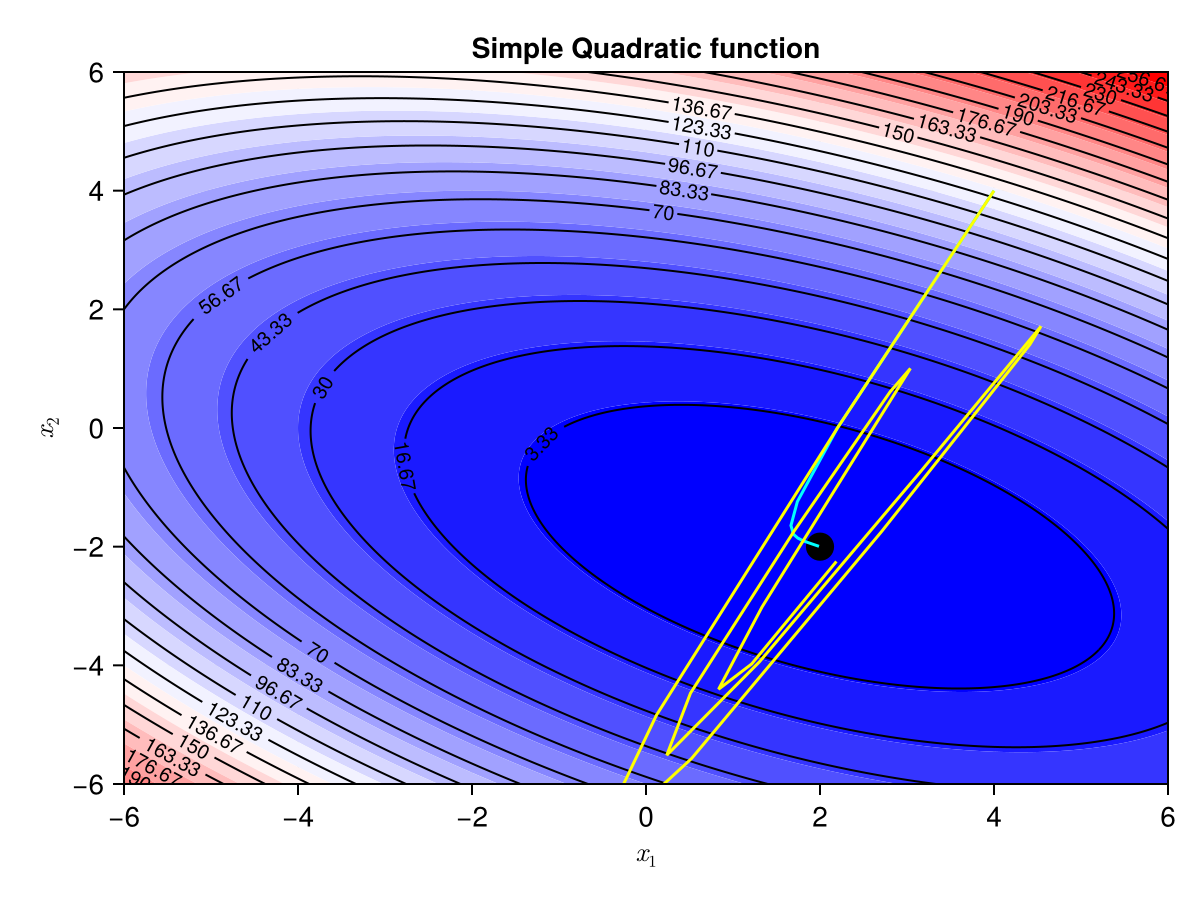

In [15]:
vec_points=[] #Define empty vector
optf = OptimizationFunction((x,p)->quad(x), ADTypes.AutoZygote())
prob = OptimizationProblem(optf, x0)
sol = solve(prob, Optimisers.Momentum(0.1,0.9);maxiters=20,callback=my_callback2D)

vec_points_m=copy(vec_points)

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",title = "Simple Quadratic function",limits=(-6,6.0,-6.0,6.0))
contourf!(ax,x1range,x2range,funcplot;  levels=20,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels=20,color=:black)
#contour!(ax,x1range,x2range,funcplot; labels=true, levels=20,colormap=:hsv)
scatter!(ax,[2],[-2];markersize=20,color=:black)

lines!(ax,getproperty.(vec_points_gd[:],:x1),getproperty.(vec_points_gd[:],:x2);color=:cyan,label="Gradient Descent")
lines!(ax,getproperty.(vec_points_m[:],:x1),getproperty.(vec_points_m[:],:x2);color=:yellow,label="Momentum")
fig

In the example above, the momentum method tends to overshoot the true solution at $(x_1,x_2)=(2,-2)$.  For this problem, seems like the standard gradient descent performs better.

## Example 2.1.2 with Nesterov Momentum method

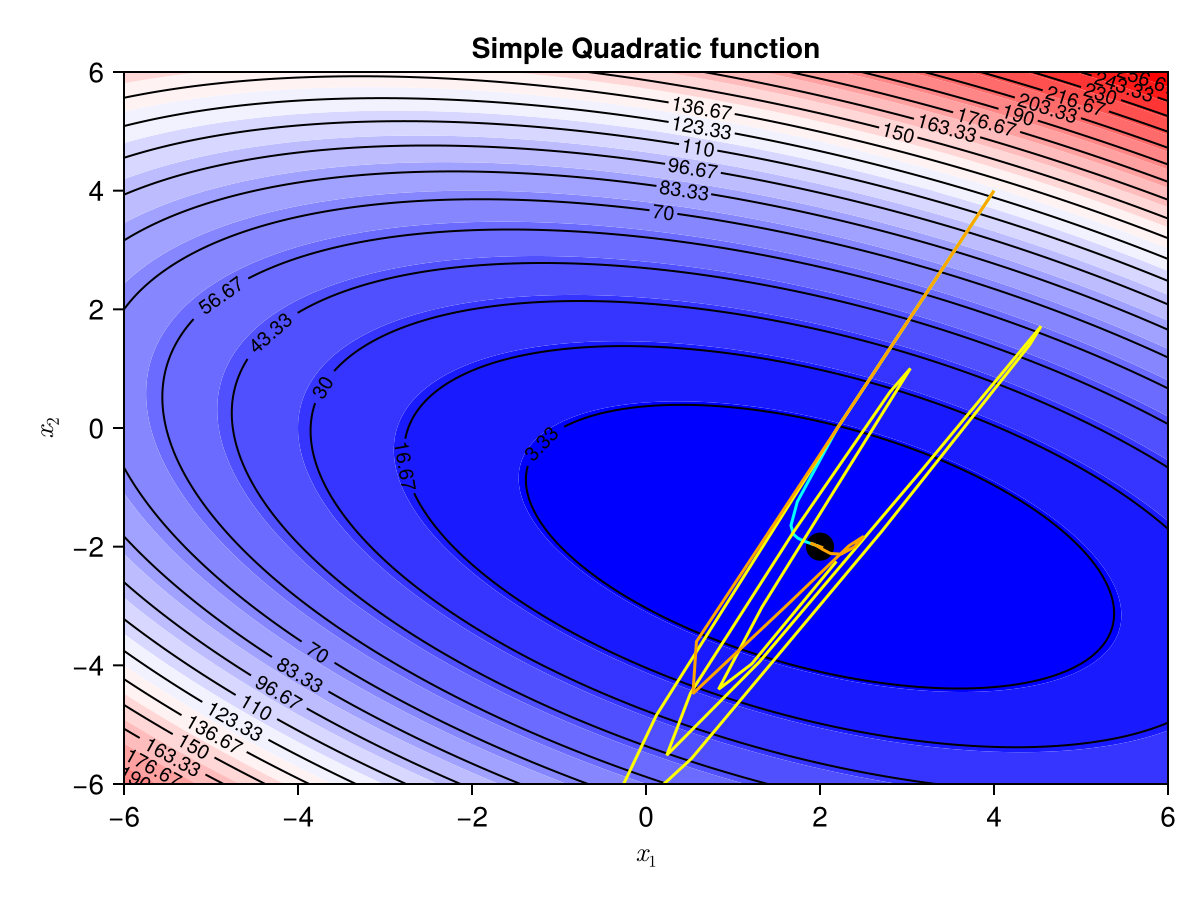

In [16]:
vec_points=[] #Define empty vector
optf = OptimizationFunction((x,p)->quad(x), ADTypes.AutoZygote())
prob = OptimizationProblem(optf, x0)
sol = solve(prob, Optimisers.Nesterov(0.1,0.9);maxiters=20,callback=my_callback2D)

vec_points_nm=copy(vec_points)

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",title = "Simple Quadratic function",limits=(-6,6.0,-6.0,6.0))
contourf!(ax,x1range,x2range,funcplot;  levels=20,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels=20,color=:black)
#contour!(ax,x1range,x2range,funcplot; labels=true, levels=20,colormap=:hsv)
scatter!(ax,[2],[-2];markersize=20,color=:black)

lines!(ax,getproperty.(vec_points_gd[:],:x1),getproperty.(vec_points_gd[:],:x2);color=:cyan,label="Gradient Descent")
lines!(ax,getproperty.(vec_points_m[:],:x1),getproperty.(vec_points_m[:],:x2);color=:yellow,label="Momentum")
lines!(ax,getproperty.(vec_points_nm[:],:x1),getproperty.(vec_points_nm[:],:x2);color=:orange,label="Nesterov Momentum")
fig

---

## **Example 2.1.3**

In this example, we will use the same methods to find the minimum of the Rosenbrock function.  

$f(x_1,x_2)=(1-x_1)^2+(x_2-x_1^2)^2$


Recall that the local minimum of this function is located at $(x_1,x_2)=(1.0,1.0)$.

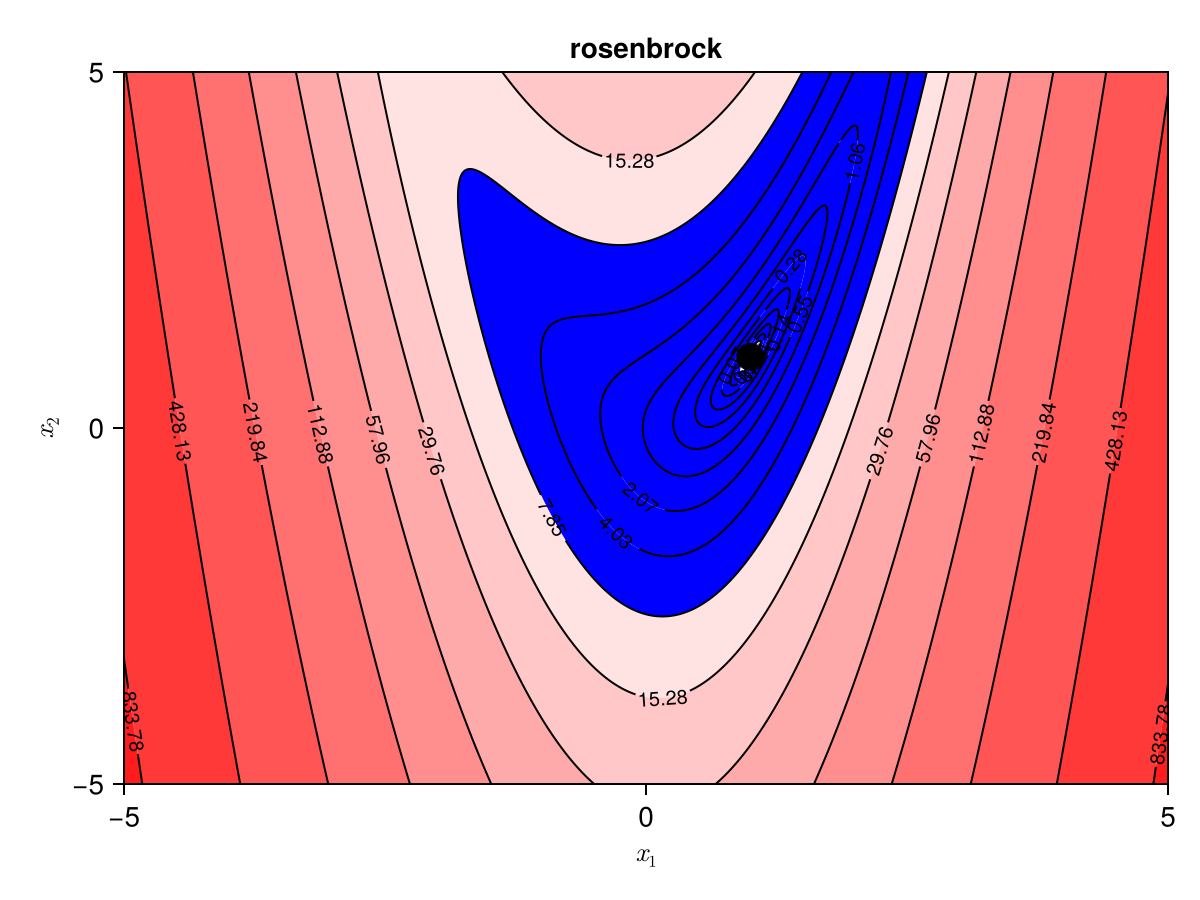

In [17]:
rosenbrock(x) = (1.0 - x[1])^2 + 1.0* (x[2] - x[1]^2)^2

x1range=-5:0.02:5;
x2range=-5:0.02:5;
funcplot = [rosenbrock([x1,x2]) for x1 in x1range, x2 in x2range]

fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_1", ylabel = L"x_2",title = "rosenbrock",limits=(-5,5.0,-5.0,5.0))
levels = 10.0.^range(-2, 3.5; length=20)
contourf!(ax,x1range,x2range,funcplot;  levels,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels,color=:black)
scatter!(ax,[1],[1];markersize=20,color=:black)
fig

We will now use standard gradient descend, Nesterov momentum and Adam to try to find the minimum of this function

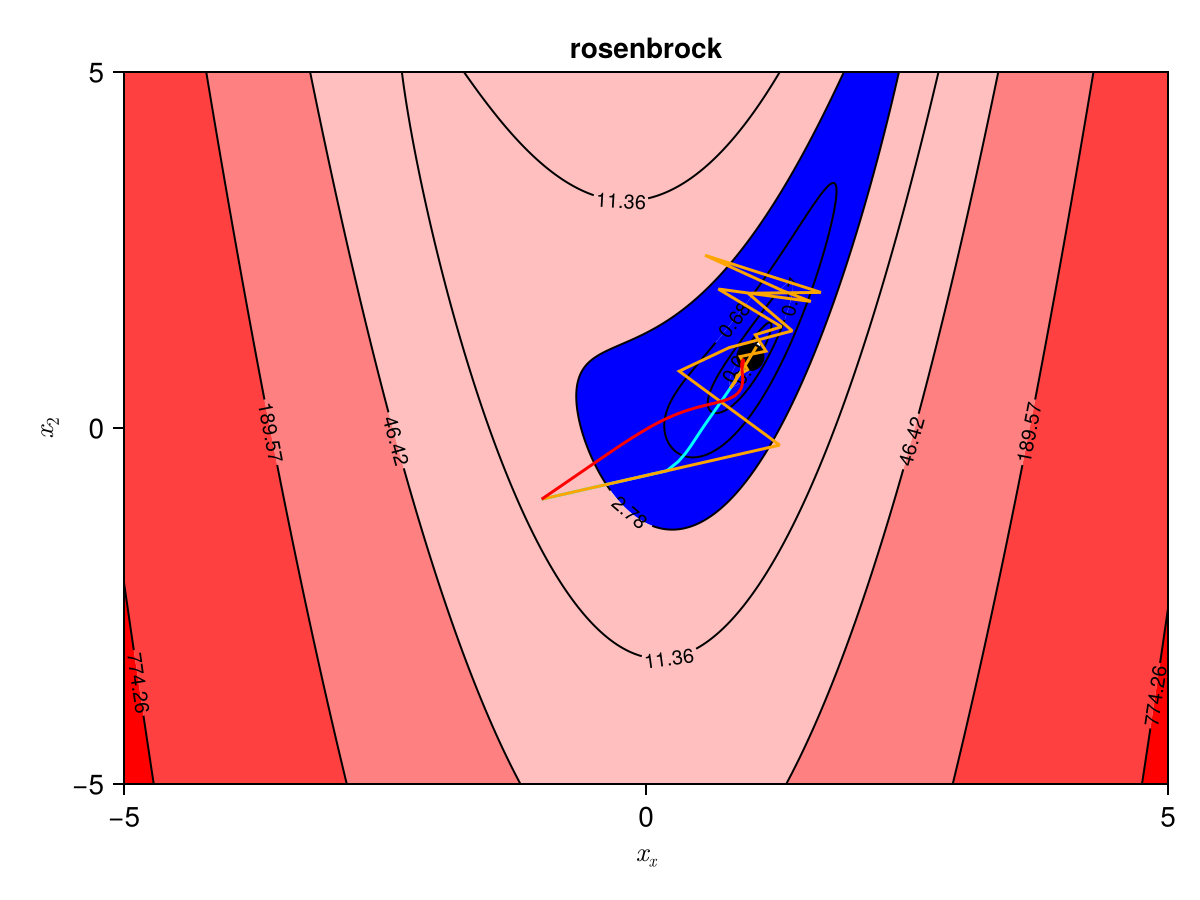

In [18]:
x0=-1.0*ones(2)
vec_points=[] #Define empty vector
optf = OptimizationFunction((x,p)->rosenbrock(x), ADTypes.AutoZygote())
prob = OptimizationProblem(optf, x0)

sol = solve(prob, Optimisers.Descent(0.1);maxiters=50,callback=my_callback2D)
vec_points_gd=copy(vec_points)

vec_points=[]
sol = solve(prob, Optimisers.Nesterov(0.1,0.9);maxiters=50,callback=my_callback2D)
vec_points_nm=copy(vec_points)

vec_points=[]
sol = solve(prob, Optimisers.Adam(0.1,(0.9,0.999));maxiters=50,callback=my_callback2D)
vec_points_ad=copy(vec_points)


fig = Figure()
ax = Axis(fig[1, 1], xlabel = L"x_x", ylabel = L"x_2",title = "rosenbrock",limits=(-5,5.0,-5.0,5.0))
levels = 10.0.^range(-2, 3.5; length=10)
contourf!(ax,x1range,x2range,funcplot;  levels,colormap=:bwr)
contour!(ax,x1range,x2range,funcplot; labels=true, levels,color=:black)
scatter!(ax,[1],[1];markersize=20,color=:black)

lines!(ax,getproperty.(vec_points_gd[:],:x1),getproperty.(vec_points_gd[:],:x2);color=:cyan,label="Gradient Descent")
lines!(ax,getproperty.(vec_points_nm[:],:x1),getproperty.(vec_points_nm[:],:x2);color=:orange,label="Nesterov Momentum")
lines!(ax,getproperty.(vec_points_ad[:],:x1),getproperty.(vec_points_ad[:],:x2);color=:red,label="Adam")
fig

Note that the gradient descent method covergfes very slowly to the exact solution $(1,1)$.   Nesterov Momentum and Adam converges faster

In [19]:
vec_points_ad

51-element Vector{Any}:
 Point2D(-1.0, -1.0, 8.0)
 Point2D(-0.9000000000833334, -0.9000000002499999, 6.534100001684667)
 Point2D(-0.8009138308597932, -0.8007104082179927, 5.32315466305075)
 Point2D(-0.7033589100664497, -0.7026961196358987, 4.335221987658899)
 Point2D(-0.6079086784434856, -0.6065792372654626, 3.5382043873426454)
 Point2D(-0.5150556375537603, -0.5130222111584839, 2.901151512190348)
 Point2D(-0.4251842938595384, -0.42270460793821907, 2.395345975713274)
 Point2D(-0.3385575131674313, -0.3362947107871864, 1.995061365389093)
 Point2D(-0.2553165298261212, -0.2544180808891316, 1.67796669761354)
 Point2D(-0.17549223918168882, -0.17762593007566324, 1.425222341424325)
 ⋮
 Point2D(0.917264179201712, 0.858961795848774, 0.0071545615752586535)
 Point2D(0.9166857630635609, 0.8829866774751655, 0.008762322901878072)
 Point2D(0.9171502456074866, 0.9040557753546898, 0.010819385134270236)
 Point2D(0.9188006202161787, 0.9220487435916058, 0.012654610111038075)
 Point2D(0.9217046766852283, 0.9

We can print out more information about the final solution if we like

In [20]:
println("Optimal parameters u:", sol.u)
println("Optimal objective value:", sol.objective)
println("Convergence status:",sol.retcode)

Optimal parameters u:[0.9186669849781277, 0.8322028873766927]
Optimal objective value:0.006753031182367552
Convergence status:Default


<u>Exercise Ex05:</u> Generalize the code above such that you can find the minimum of the rosenbrock function

$f(x_1,x_2,p_1,p_2)=(p_1-x_1)^2+p_2(x_2-x_1^2)^2$

for different values of $p_1$ and $p_2$.

---

**Class Demo 02:**.Use the Julia functions to find the minimum of the Himmelblau function $h(x_1,x_2)=(x_1^2+x_2-11)^2+(x_1+x_2^2-7)^2$.

---